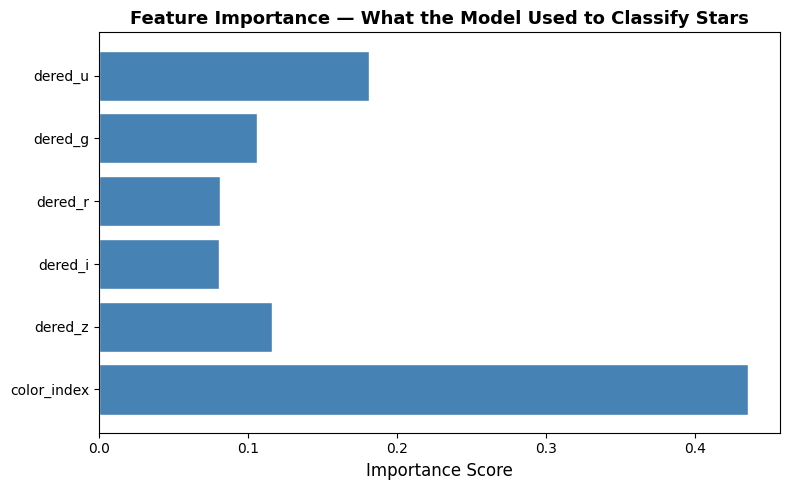

In [ ]:
importances = model.feature_importances_
features = ['dered_u', 'dered_g', 'dered_r', 'dered_i', 'dered_z', 'color_index']

plt.figure(figsize=(8, 5))
bars = plt.barh(features, importances, color='steelblue', edgecolor='white')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — What the Model Used to Classify Stars', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

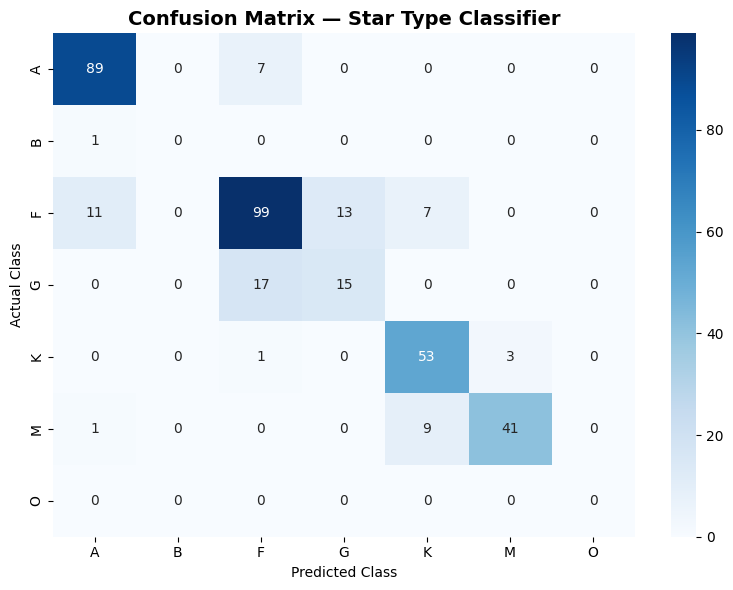

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Confusion Matrix — Star Type Classifier', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Prepare data — only keep stars with known spectral class
df_ml = df[df['subClass'].str.match(r'^[OBAFGKM]', na=False)].copy()
df_ml['spectral_class'] = df_ml['subClass'].str[0]  # just first letter

# Features: color indices across bands
X = df_ml[['dered_u', 'dered_g', 'dered_r', 'dered_i', 'dered_z', 'color_index']]
y = df_ml['spectral_class']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("✅ Model Accuracy:", round(model.score(X_test, y_test) * 100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

✅ Model Accuracy: 80.93 %

Detailed Report:
              precision    recall  f1-score   support

           A       0.87      0.93      0.90        96
           B       0.00      0.00      0.00         1
           F       0.80      0.76      0.78       130
           G       0.54      0.47      0.50        32
           K       0.77      0.93      0.84        57
           M       0.93      0.80      0.86        51

    accuracy                           0.81       367
   macro avg       0.65      0.65      0.65       367
weighted avg       0.81      0.81      0.81       367



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


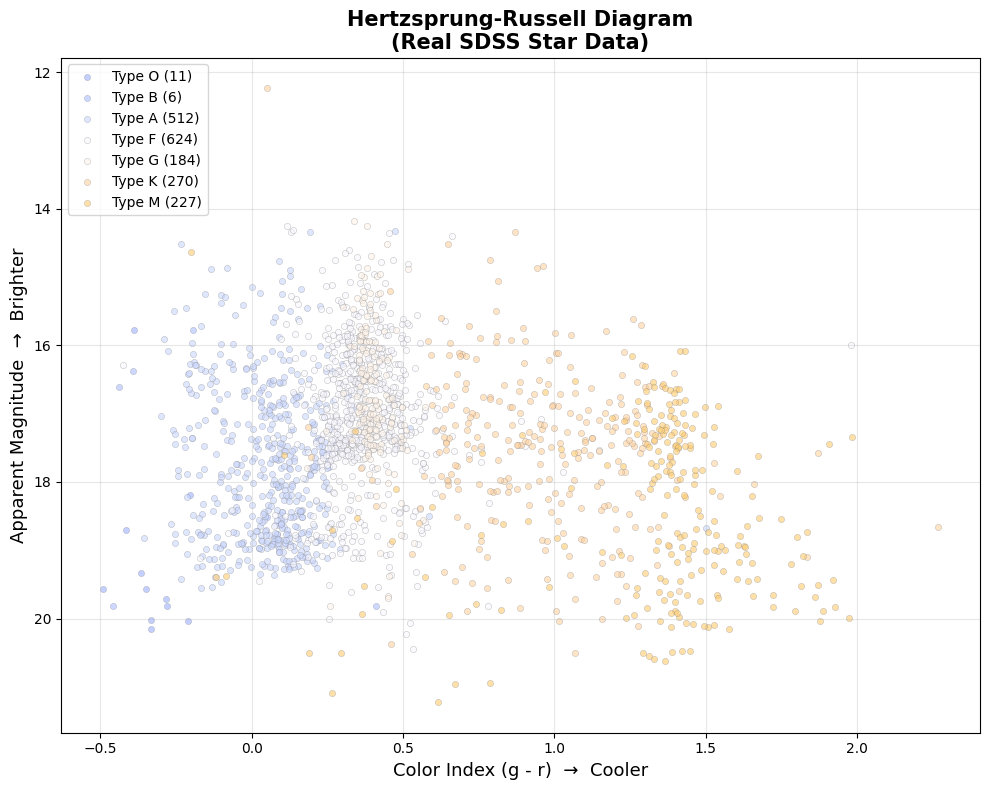

HR Diagram saved as hr_diagram.png!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Color map each spectral class
spectral_colors = {
    'O': '#9bb0ff',   # blue
    'B': '#aabfff',   # blue-white
    'A': '#cad7ff',   # white
    'F': '#f8f7ff',   # yellow-white
    'G': '#fff4ea',   # yellow
    'K': '#ffd2a1',   # orange
    'M': '#ffcc6f',   # red-orange
}

fig, ax = plt.subplots(figsize=(10, 8))

# Plot each spectral class separately
for sclass, color in spectral_colors.items():
    subset = df[df['subClass'].str.startswith(sclass, na=False)]
    if len(subset) > 0:
        ax.scatter(
            subset['color_index'],
            subset['magnitude'],
            c=color,
            label=f'Type {sclass} ({len(subset)})',
            alpha=0.6,
            edgecolors='gray',
            linewidths=0.3,
            s=20
        )

# HR diagrams have FLIPPED y-axis (brighter = lower magnitude number = top)
ax.invert_yaxis()

ax.set_xlabel('Color Index (g - r)  →  Cooler', fontsize=13)
ax.set_ylabel('Apparent Magnitude  →  Brighter', fontsize=13)
ax.set_title('Hertzsprung-Russell Diagram\n(Real SDSS Star Data)', fontsize=15, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hr_diagram.png', dpi=150)
plt.show()

print("HR Diagram saved as hr_diagram.png!")

In [ ]:
# Drop rows with missing values
df = df.dropna()

# Compute Color Index (B-V proxy using SDSS bands)
# g - r is the standard SDSS proxy for temperature
df['color_index'] = df['dered_g'] - df['dered_r']

# Absolute magnitude (we'll use dered_r as our brightness measure)
df['magnitude'] = df['dered_r']

# Filter out bad/weird readings
df = df[df['color_index'].between(-0.5, 2.5)]
df = df[df['magnitude'].between(10, 22)]

print(f"Clean stars ready to plot: {len(df)}")
print(df[['subClass', 'color_index', 'magnitude']].head(10))

Clean stars ready to plot: 1991
  subClass  color_index  magnitude
0       A0     -0.10250   17.88674
1       WD     -0.22177   16.46955
2       WD     -0.17356   18.11127
3       WD     -0.35629   20.09459
4       WD     -0.22062   18.76031
5       G2      0.43029   16.17973
6       M6      1.52700   17.19412
7       G2      0.45081   17.85673
8       G2      0.36925   16.07521
9       F9      0.49908   15.61634


In [ ]:
from astroquery.sdss import SDSS
import pandas as pd

# Query SDSS for 2000 stars with photometric measurements
query = """
SELECT TOP 2000
    s.specobjid, s.subClass,
    s.dered_u, s.dered_g, s.dered_r, s.dered_i, s.dered_z
FROM SpecPhoto AS s
WHERE s.class = 'STAR'
  AND s.dered_g BETWEEN 10 AND 22
  AND s.dered_r BETWEEN 10 AND 22
"""

from astroquery.sdss import SDSS
result = SDSS.query_sql(query)
df = result.to_pandas()
print(df.head())
print(f"\nTotal stars fetched: {len(df)}")

            specobjid subClass   dered_u   dered_g   dered_r   dered_i  \
0  299493525735630848       A0  19.06117  17.78424  17.88674  17.99026   
1  299496549392607232       WD  16.62827  16.24778  16.46955  16.68320   
2  299497923782141952       WD  18.25325  17.93771  18.11127  18.29147   
3  299498198660048896       WD  20.05437  19.73830  20.09459  20.34895   
4  299499573049583616       WD  18.93180  18.53969  18.76031  18.97593   

    dered_z  
0  18.10927  
1  16.91622  
2  18.47079  
3  20.96147  
4  19.20880  

Total stars fetched: 2000


In [ ]:
!pip install astropy astroquery pandas matplotlib numpy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.4 MB/s eta 0:00:00
